# Flood Detection from Satellite Images — CNN Classification Project
**Author:** Achyuth Reddy · MSc Data Science, UE Germany
**Course:** Machine Learning — Phase 2 (Proposal, Code Development and Technical Implementation)
**Supervisor:** Prof. Shan Faiz

**Dataset:** [Flood Area Segmentation](https://www.kaggle.com/datasets/faizalkarim/flood-area-segmentation) (Kaggle)

This notebook implements the full pipeline described in the project proposal:
1. Dataset loading & label derivation (binary: Flooded vs Non-Flooded)
2. Preprocessing (resize, normalize)
3. Train / validation / test split
4. Data augmentation
5. Custom CNN model
6. Transfer learning (MobileNetV2, VGG16, ResNet50) with two-phase fine-tuning
7. Evaluation: accuracy/loss curves, confusion matrix, classification report, ROC curves
8. Grad-CAM visualization & error analysis
9. Model comparison table


In [1]:
# ============================================================
# 1. SETUP & IMPORTS
# ============================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_fscore_support)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
os.makedirs("figures", exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================================
# 1b. DATASET STRUCTURE CHECK — run this first and look at the output
# ============================================================
# On Kaggle, confirm what was actually attached before assuming folder names/paths.
if os.path.exists("/kaggle/input"):
    print("Contents of /kaggle/input:")
    for entry in os.listdir("/kaggle/input"):
        print(" -", entry)
    print()
    for root, dirs, files in os.walk("/kaggle/input"):
        depth = root.replace("/kaggle/input", "").count(os.sep)
        if depth <= 2:
            print(f"{'  '*depth}{os.path.basename(root) or root}/  ({len(files)} files)" )
else:
    print("/kaggle/input not found — you are likely running locally. "
          "Download the dataset from Kaggle and set SEARCH_ROOTS in the next cell accordingly.")


Contents of /kaggle/input:
 - datasets

input/  (0 files)
  datasets/  (0 files)
    faizalkarim/  (0 files)


## 2. Dataset Loading

On Kaggle, attach the dataset **Flood Area Segmentation** (`faizalkarim/flood-area-segmentation`).
It provides an `Image/` folder of satellite images and a `Mask/` folder of binary ground-truth masks
(white = flooded water pixels, black = non-flooded).

We derive **binary classification labels** from the masks: an image is labeled **Flooded (1)** if the
proportion of flood-labeled (white) pixels in its mask exceeds a threshold, otherwise **Non-Flooded (0)**.

In [3]:
# ============================================================
# 2. DATASET LOADING & LABEL DERIVATION (robust path auto-detection)
# ============================================================
# Kaggle sometimes nests the dataset root (e.g. .../flood-area-segmentation/flood-area-segmentation/Image),
# and folder casing / file extensions can vary between mirrors of this dataset.
# Instead of hard-coding a path, we search for the Image/Mask folders automatically.

SEARCH_ROOTS = ["/kaggle/input", "./data", "."]
IMG_EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

def find_image_mask_dirs(search_roots):
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for dirpath, dirnames, filenames in os.walk(root):
            lower_dirnames = {d.lower(): d for d in dirnames}
            if "image" in lower_dirnames and "mask" in lower_dirnames:
                image_dir = os.path.join(dirpath, lower_dirnames["image"])
                mask_dir = os.path.join(dirpath, lower_dirnames["mask"])
                return image_dir, mask_dir
    return None, None

IMAGE_DIR, MASK_DIR = find_image_mask_dirs(SEARCH_ROOTS)

if IMAGE_DIR is None:
    raise FileNotFoundError(
        "Could not locate 'Image'/'Mask' folders under /kaggle/input. "
        "Run `!ls /kaggle/input` and `!find /kaggle/input -maxdepth 3` in a new cell "
        "to inspect the actual dataset structure, then set IMAGE_DIR / MASK_DIR manually."
    )

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)

image_paths = sorted([
    os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.endswith(IMG_EXTS)
])
print(f"Found {len(image_paths)} images")
assert len(image_paths) > 0, "No images found — check IMAGE_DIR path/extensions above."

# Build a lookup of mask files by their filename stem (without extension),
# since mask extensions may differ from image extensions (e.g. .jpg image -> .png mask).
mask_files_by_stem = {}
for f in os.listdir(MASK_DIR):
    if f.endswith(IMG_EXTS):
        stem = os.path.splitext(f)[0]
        mask_files_by_stem[stem] = os.path.join(MASK_DIR, f)

FLOOD_PIXEL_THRESHOLD = 0.15   # >15% flooded pixels in mask -> label as 'Flooded'

records = []
skipped = 0
for img_path in tqdm(image_paths, desc="Deriving labels from masks"):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    mask_path = mask_files_by_stem.get(stem)
    if mask_path is None or not os.path.exists(mask_path):
        skipped += 1
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        skipped += 1
        continue
    flood_ratio = float(np.mean(mask > 127))
    label = 1 if flood_ratio > FLOOD_PIXEL_THRESHOLD else 0
    records.append({"image_path": img_path, "flood_ratio": flood_ratio, "label": label})

print(f"Matched {len(records)} image-mask pairs, skipped {skipped} (no matching mask found)")

df = pd.DataFrame(records)
assert len(df) > 0, "No image-mask pairs were matched — inspect filenames in IMAGE_DIR/MASK_DIR."

df["class_name"] = df["label"].map({0: "Non-Flooded", 1: "Flooded"})
print(df["class_name"].value_counts())
df.head()


IMAGE_DIR: /kaggle/input/datasets/faizalkarim/flood-area-segmentation/Image
MASK_DIR : /kaggle/input/datasets/faizalkarim/flood-area-segmentation/Mask
Found 290 images


Deriving labels from masks: 100%|██████████| 290/290 [00:03<00:00, 96.22it/s]

Matched 290 image-mask pairs, skipped 0 (no matching mask found)
class_name
Flooded        269
Non-Flooded     21
Name: count, dtype: int64


,image_path,flood_ratio,label,class_name
0,/kaggle/input/datasets/faizalkarim/flood-area-...,0.249503,1,Flooded
1,/kaggle/input/datasets/faizalkarim/flood-area-...,0.252440,1,Flooded
2,/kaggle/input/datasets/faizalkarim/flood-area-...,0.296557,1,Flooded
3,/kaggle/input/datasets/faizalkarim/flood-area-...,0.389403,1,Flooded
4,/kaggle/input/datasets/faizalkarim/flood-area-...,0.457352,1,Flooded


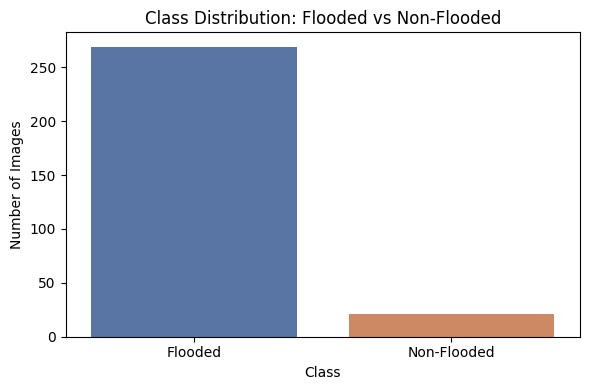

In [4]:
# ============================================================
# 2b. CLASS DISTRIBUTION VISUALIZATION
# ============================================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class_name", hue="class_name", palette=["#4C72B0", "#DD8452"], legend=False)
plt.title("Class Distribution: Flooded vs Non-Flooded")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=150)
plt.show()


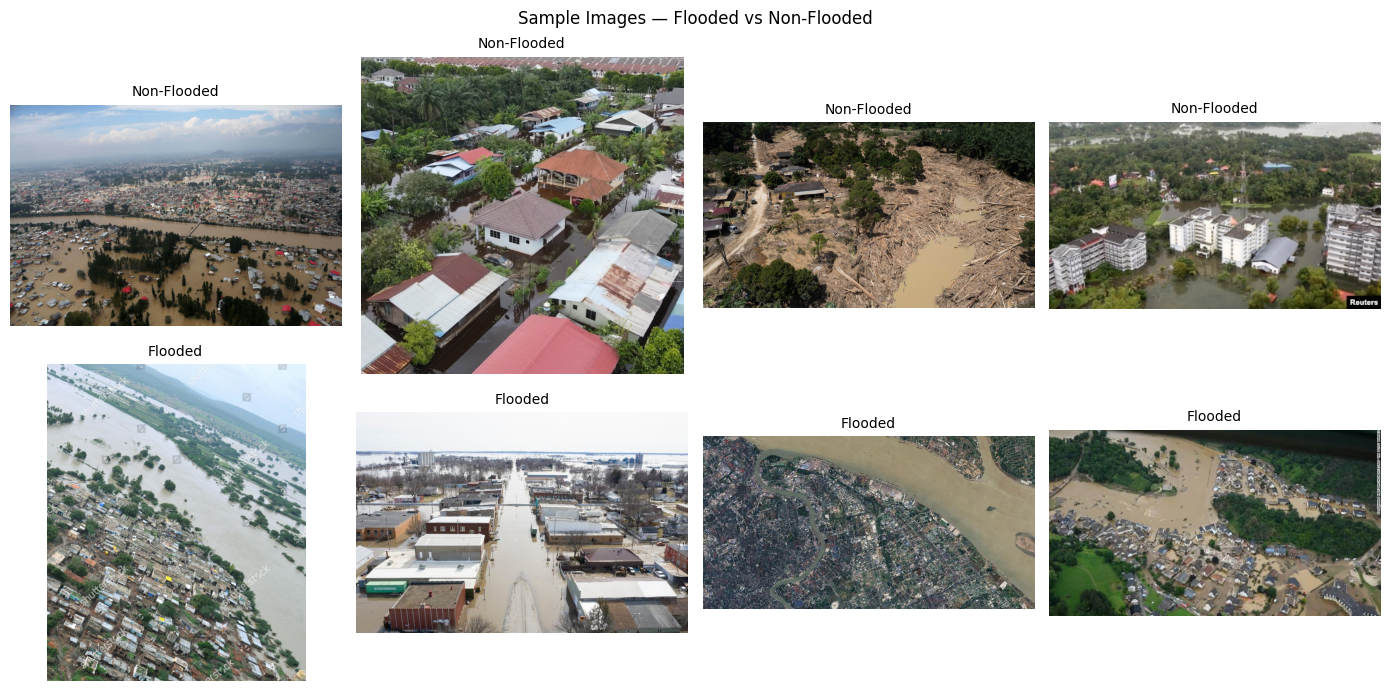

In [5]:
# ============================================================
# 2c. SAMPLE IMAGES FROM EACH CLASS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, label in enumerate([0, 1]):
    samples = df[df["label"] == label].sample(4, random_state=SEED)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].set_title(row["class_name"], fontsize=10)
        axes[i, j].axis("off")
plt.suptitle("Sample Images — Flooded vs Non-Flooded")
plt.tight_layout()
plt.savefig("figures/sample_images.png", dpi=150)
plt.show()


## 3. Preprocessing: Resize & Normalize

All images are resized to **224×224** (matching the input requirements of the pretrained
transfer-learning backbones) and pixel values are normalized to the **[0, 1]** range.

In [6]:
# ============================================================
# 3. PREPROCESSING — RESIZE & NORMALIZE
# ============================================================
def load_and_preprocess(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = img.astype("float32") / 255.0
    return img

X = np.array([load_and_preprocess(p) for p in tqdm(df["image_path"], desc="Loading & preprocessing images")])
y = df["label"].values
print("X shape:", X.shape, "| y shape:", y.shape)


Loading & preprocessing images: 100%|██████████| 290/290 [00:06<00:00, 44.88it/s]

X shape: (290, 224, 224, 3) | y shape: (290,)


## 4. Train / Validation / Test Split

Stratified split: **70% train / 15% validation / 15% test**, preserving class balance.

In [7]:
# ============================================================
# 4. TRAIN / VALIDATION / TEST SPLIT (70/15/15, stratified)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Class weights to address any residual imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Train: 203 | Val: 43 | Test: 44
Class weights: {0: np.float64(6.766666666666667), 1: np.float64(0.5398936170212766)}


## 5. Data Augmentation

Augmentation (rotation, flips, zoom, brightness shift, shear) is applied **only to the training set**
via `ImageDataGenerator.flow()`, to improve generalization without leaking augmented validation/test data.

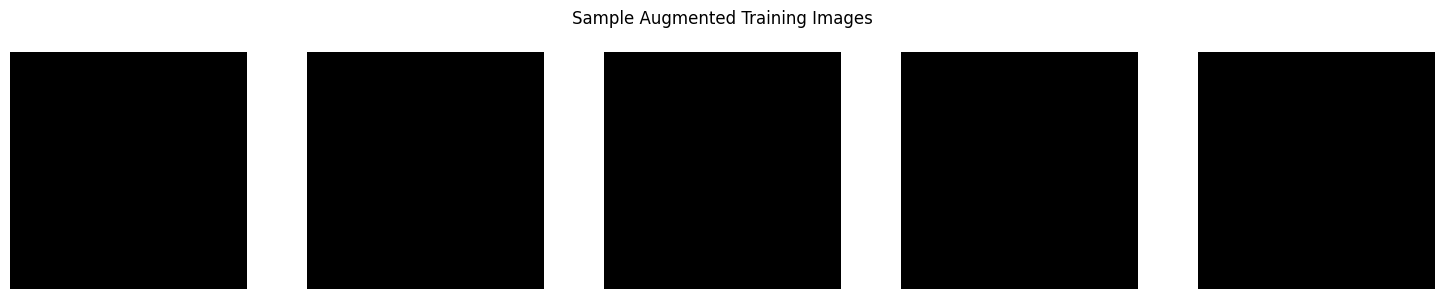

In [8]:
# ============================================================
# 5. DATA AUGMENTATION (training set only)
# ============================================================
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest",
)
val_test_datagen = ImageDataGenerator()  # no augmentation, only pass-through

train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_generator   = val_test_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_generator  = val_test_datagen.flow(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

# Visualize a few augmented samples
sample_batch, _ = next(train_generator)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(sample_batch[i])
    axes[i].axis("off")
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.savefig("figures/augmentation_samples.png", dpi=150)
plt.show()


## 6. Custom CNN Model (Baseline)

Four convolutional blocks (Conv2D → BatchNorm → MaxPool) with increasing filter depth
(32 → 64 → 128 → 256), followed by Global Average Pooling, a Dense(128) head with Dropout(0.5),
and a sigmoid output for binary classification.

In [9]:
# ============================================================
# 6. CUSTOM CNN MODEL
# ============================================================
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ], name="Custom_CNN")
    return model

custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)
custom_cnn.summary()


I0000 00:00:1783375820.497716      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783375820.500875      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
# ============================================================
# 6b. TRAIN CUSTOM CNN
# ============================================================
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history_cnn = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
)


Epoch 1/40
1/7 ━━━━━━━━━━━━━━━━━━━━ 1:08 11s/step - accuracy: 0.8125 - auc: 0.9250 - loss: 0.6399

I0000 00:00:1783375834.141007      79 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8276 - auc: 0.4434 - loss: 0.8611 - val_accuracy: 0.0698 - val_auc: 0.1125 - val_loss: 0.7770 - learning_rate: 0.0010
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 387ms/step - accuracy: 0.7389 - auc: 0.5860 - loss: 0.7570 - val_accuracy: 0.0698 - val_auc: 0.1667 - val_loss: 1.0461 - learning_rate: 0.0010
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.8079 - auc: 0.5778 - loss: 0.6633 - val_accuracy: 0.0698 - val_auc: 0.1208 - val_loss: 1.2653 - learning_rate: 0.0010
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 0.7685 - auc: 0.4668 - loss: 0.7693 - val_accuracy: 0.0698 - val_auc: 0.1208 - val_loss: 1.1672 - learning_rate: 0.0010
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 347ms/step - accuracy: 0.5517 - auc: 0.4807 - loss: 0.8951 - val_accuracy: 0.0698 - val_auc: 0.1292 - val_loss: 1.1614 - learning_rate: 5.0000e-04
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - accuracy: 0.5567 - auc: 0.5582 - loss: 0.6702 -

## 7. Transfer Learning Models: MobileNetV2, VGG16, ResNet50

Each backbone is loaded with ImageNet weights (top layers excluded). A new classification head
(Global Average Pooling → Dense → Dropout → Sigmoid) is attached. Training uses **two phases**:

- **Phase 1:** freeze the pretrained base, train only the new head.
- **Phase 2:** unfreeze the top layers of the base and fine-tune end-to-end at a lower learning rate.

In [11]:
# ============================================================
# 7. TRANSFER LEARNING — MODEL BUILDER
# ============================================================
def build_transfer_model(base_model_fn, name):
    base_model = base_model_fn(weights="imagenet", include_top=False,
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False  # Phase 1: freeze base

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name=name)
    model.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model, base_model

def fine_tune_phase2(model, base_model, unfreeze_from=-30, lr=1e-5):
    base_model.trainable = True
    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False
    model.compile(optimizer=optimizers.Adam(lr), loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model


In [12]:
# ============================================================
# 7a. MOBILENETV2
# ============================================================
mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, "MobileNetV2")
history_mobilenet_p1 = mobilenet_model.fit(train_generator, validation_data=val_generator,
                                            epochs=15, class_weight=class_weight_dict,
                                            callbacks=[early_stop, reduce_lr])

mobilenet_model = fine_tune_phase2(mobilenet_model, mobilenet_base, unfreeze_from=-30, lr=1e-5)
history_mobilenet_p2 = mobilenet_model.fit(train_generator, validation_data=val_generator,
                                            epochs=15, class_weight=class_weight_dict,
                                            callbacks=[early_stop, reduce_lr])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


2026-07-06 22:11:14.868773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 22:11:15.005580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/7 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.2951 - auc: 0.4821 - loss: 0.9923

2026-07-06 22:11:26.562609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 22:11:26.698335: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.7044 - auc: 0.5819 - loss: 0.8987 - val_accuracy: 0.9302 - val_auc: 0.4958 - val_loss: 0.2729 - learning_rate: 0.0010
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - accuracy: 0.3448 - auc: 0.5090 - loss: 0.9322 - val_accuracy: 0.1860 - val_auc: 0.7750 - val_loss: 1.0197 - learning_rate: 0.0010
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step - accuracy: 0.7537 - auc: 0.5559 - loss: 0.8506 - val_accuracy: 0.0698 - val_auc: 0.7375 - val_loss: 1.6735 - learning_rate: 0.0010
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.4039 - auc: 0.5277 - loss: 0.8177 - val_accuracy: 0.0698 - val_auc: 0.6000 - val_loss: 2.2799 - learning_rate: 0.0010
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.3645 - auc: 0.6028 - loss: 0.7799 - val_accuracy: 0.0698 - val_auc: 0.6708 - val_loss: 1.4758 - learning_rate: 5.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - accuracy: 0.4532 - auc: 0.5057 - loss: 0.7840 -

In [13]:
# ============================================================
# 7b. VGG16
# ============================================================
vgg_model, vgg_base = build_transfer_model(VGG16, "VGG16")
history_vgg_p1 = vgg_model.fit(train_generator, validation_data=val_generator,
                                epochs=15, class_weight=class_weight_dict,
                                callbacks=[early_stop, reduce_lr])

vgg_model = fine_tune_phase2(vgg_model, vgg_base, unfreeze_from=-6, lr=1e-5)
history_vgg_p2 = vgg_model.fit(train_generator, validation_data=val_generator,
                                epochs=15, class_weight=class_weight_dict,
                                callbacks=[early_stop, reduce_lr])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4877 - auc: 0.4739 - loss: 0.7493 - val_accuracy: 0.9302 - val_auc: 0.5000 - val_loss: 0.5590 - learning_rate: 0.0010
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.5567 - auc: 0.4608 - loss: 0.7504 - val_accuracy: 0.9302 - val_auc: 0.5500 - val_loss: 0.4991 - learning_rate: 0.0010
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 403ms/step - accuracy: 0.4236 - auc: 0.3562 - loss: 0.7843 - val_accuracy: 0.9302 - val_auc: 0.5125 - val_loss: 0.5366 - learning_rate: 0.0010
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 382ms/step - accuracy: 0.4335 - auc: 0.4254 - loss: 0.7568 - val_accuracy: 0.9302 - val_auc: 0.5083 - val_loss: 0.4878 - learning_rate: 5.0000e-04
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 392ms/step - accuracy: 0.5025 - auc: 0.3991 - loss: 0.7690 - val_accuracy: 0.9302 - val_auc: 0.5083 - val_loss: 0.5084 - learning_rate: 5.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━

In [14]:
# ============================================================
# 7c. RESNET50
# ============================================================
resnet_model, resnet_base = build_transfer_model(ResNet50, "ResNet50")
history_resnet_p1 = resnet_model.fit(train_generator, validation_data=val_generator,
                                      epochs=15, class_weight=class_weight_dict,
                                      callbacks=[early_stop, reduce_lr])

resnet_model = fine_tune_phase2(resnet_model, resnet_base, unfreeze_from=-30, lr=1e-5)
history_resnet_p2 = resnet_model.fit(train_generator, validation_data=val_generator,
                                      epochs=15, class_weight=class_weight_dict,
                                      callbacks=[early_stop, reduce_lr])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7340 - auc: 0.4883 - loss: 0.9621 - val_accuracy: 0.0698 - val_auc: 0.7458 - val_loss: 0.9684 - learning_rate: 0.0010
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 361ms/step - accuracy: 0.2808 - auc: 0.4844 - loss: 0.8167 - val_accuracy: 0.0698 - val_auc: 0.7125 - val_loss: 0.7771 - learning_rate: 0.0010
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 336ms/step - accuracy: 0.4384 - auc: 0.3908 - loss: 0.8219 - val_accuracy: 0.0698 - val_auc: 0.7792 - val_loss: 0.8064 - learning_rate: 0.0010
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 346ms/step - accuracy: 0.3596 - auc: 0.5824 - loss: 0.7178 - val_accuracy: 0.0698 - val_auc: 0.7500 - val_loss: 0.7830 - learning_rate: 5.0000e-04
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 351ms/step - accuracy: 0.4286 - auc: 0.3585 - loss: 0.8549 - val_accuracy: 0.2558 - val_auc: 0.6417 - val_loss: 0.7064 - learning_rate: 5.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━

## 8. Evaluation

### 8.1 Accuracy / Loss Curves

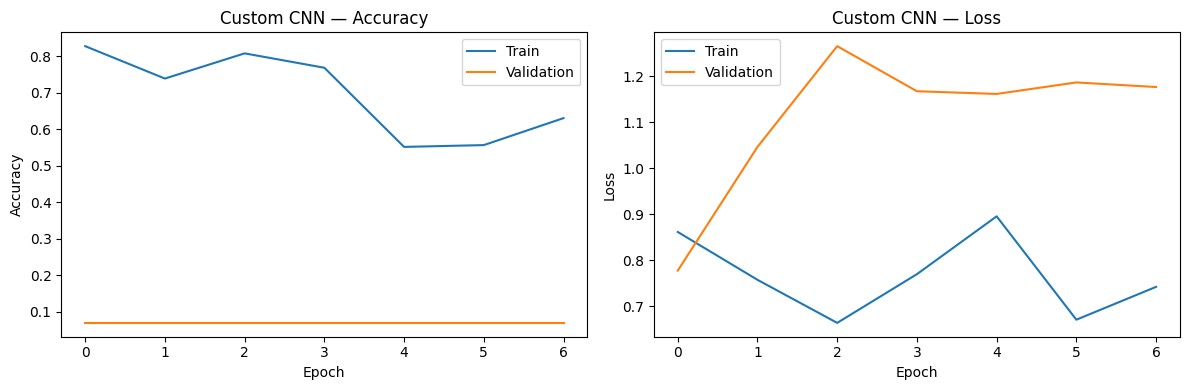

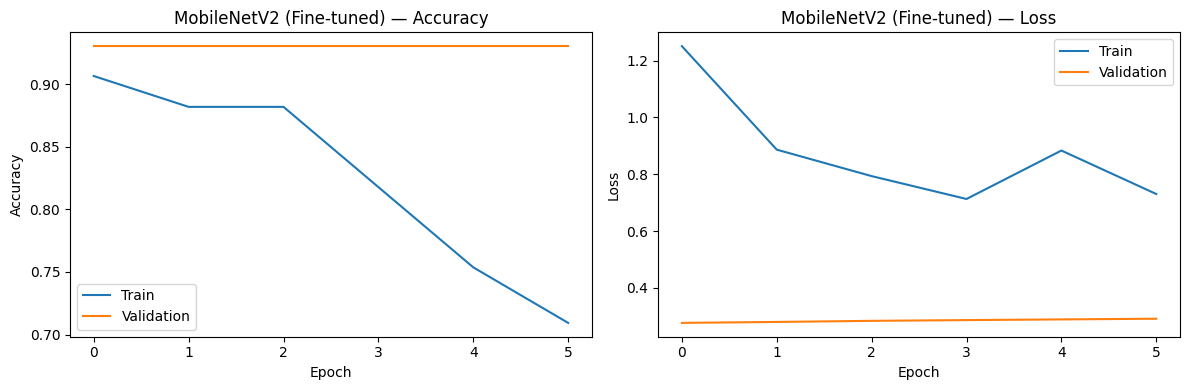

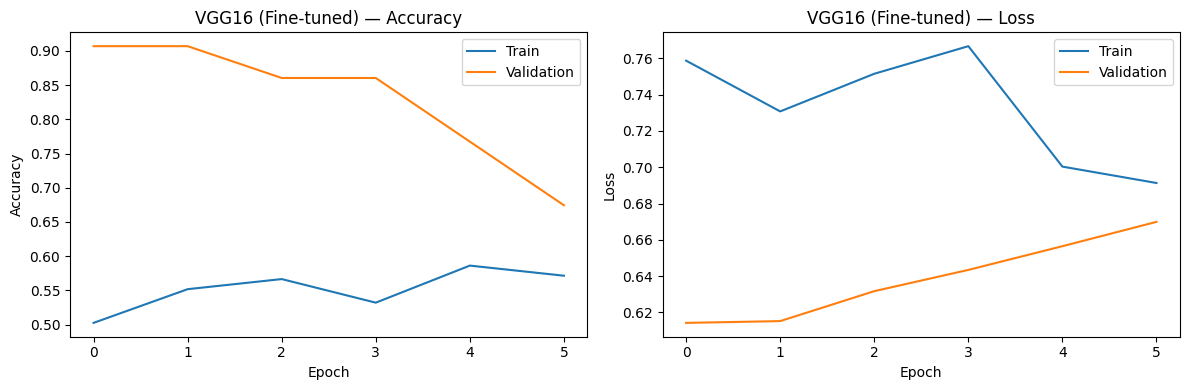

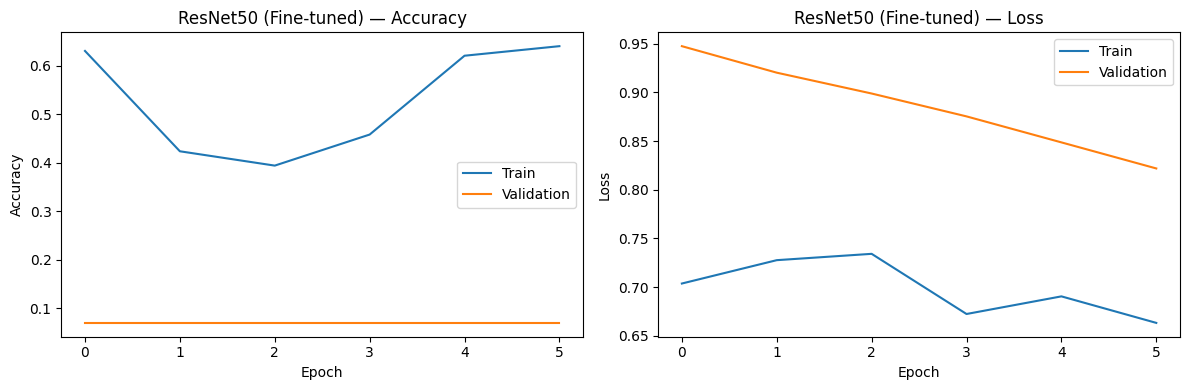

In [15]:
# ============================================================
# 8.1 ACCURACY / LOSS CURVES
# ============================================================
def plot_history(history, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Validation")
    axes[1].set_title(f"{title} — Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"figures/{filename}.png", dpi=150)
    plt.show()

plot_history(history_cnn, "Custom CNN", "custom_cnn_curves")
plot_history(history_mobilenet_p2, "MobileNetV2 (Fine-tuned)", "mobilenet_curves")
plot_history(history_vgg_p2, "VGG16 (Fine-tuned)", "vgg16_curves")
plot_history(history_resnet_p2, "ResNet50 (Fine-tuned)", "resnet50_curves")


### 8.2 Confusion Matrix, Classification Report & ROC Curve (per model)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


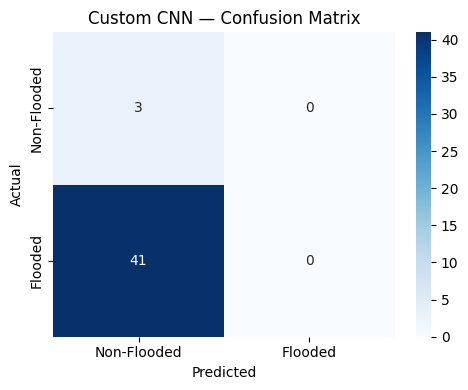


=== Custom CNN — Classification Report ===
              precision    recall  f1-score   support

 Non-Flooded       0.07      1.00      0.13         3
     Flooded       0.00      0.00      0.00        41

    accuracy                           0.07        44
   macro avg       0.03      0.50      0.06        44
weighted avg       0.00      0.07      0.01        44



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


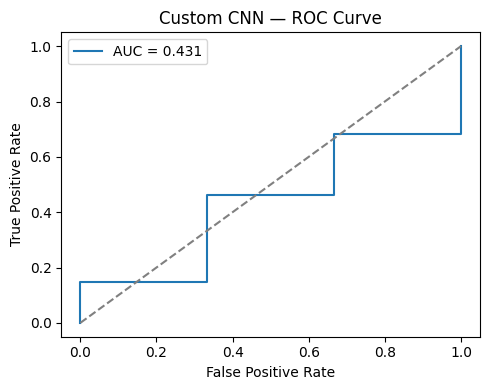

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

2026-07-06 22:15:47.931510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 22:15:48.068668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 11s/step


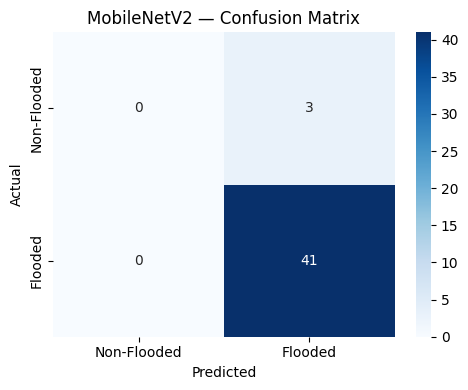


=== MobileNetV2 — Classification Report ===
              precision    recall  f1-score   support

 Non-Flooded       0.00      0.00      0.00         3
     Flooded       0.93      1.00      0.96        41

    accuracy                           0.93        44
   macro avg       0.47      0.50      0.48        44
weighted avg       0.87      0.93      0.90        44



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


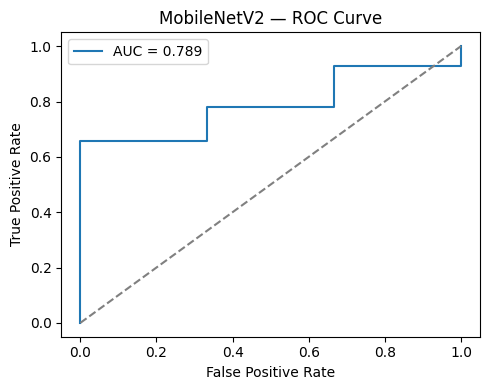

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f9cf0f3d4e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 8s/step


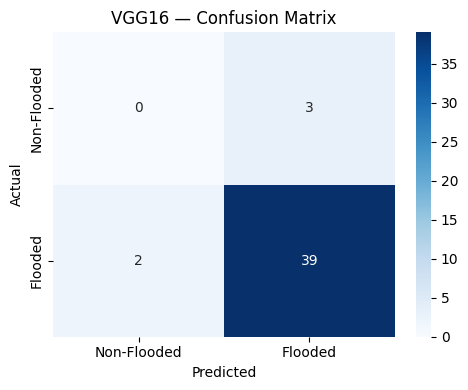


=== VGG16 — Classification Report ===
              precision    recall  f1-score   support

 Non-Flooded       0.00      0.00      0.00         3
     Flooded       0.93      0.95      0.94        41

    accuracy                           0.89        44
   macro avg       0.46      0.48      0.47        44
weighted avg       0.87      0.89      0.88        44



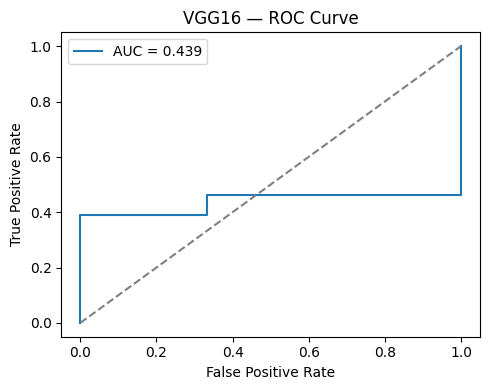

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step


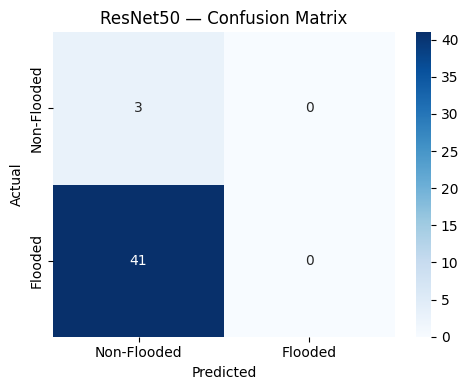


=== ResNet50 — Classification Report ===
              precision    recall  f1-score   support

 Non-Flooded       0.07      1.00      0.13         3
     Flooded       0.00      0.00      0.00        41

    accuracy                           0.07        44
   macro avg       0.03      0.50      0.06        44
weighted avg       0.00      0.07      0.01        44



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


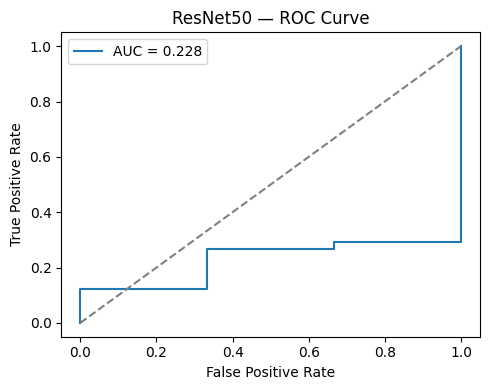

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# ============================================================
# 8.2 EVALUATION HELPER: CONFUSION MATRIX + REPORT + ROC
# ============================================================
def evaluate_model(model, name, X_test, y_test, filename_prefix):
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Flooded", "Flooded"],
                yticklabels=["Non-Flooded", "Flooded"])
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"figures/{filename_prefix}_confusion_matrix.png", dpi=150)
    plt.show()

    # Classification Report
    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=["Non-Flooded", "Flooded"]))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"{name} — ROC Curve")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"figures/{filename_prefix}_roc_curve.png", dpi=150)
    plt.show()

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
    accuracy = (y_pred == y_test).mean()
    return {"Model": name, "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1-score": f1, "AUC": roc_auc}

results = []
results.append(evaluate_model(custom_cnn, "Custom CNN", X_test, y_test, "custom_cnn"))
results.append(evaluate_model(mobilenet_model, "MobileNetV2", X_test, y_test, "mobilenet"))
results.append(evaluate_model(vgg_model, "VGG16", X_test, y_test, "vgg16"))
results.append(evaluate_model(resnet_model, "ResNet50", X_test, y_test, "resnet50"))


### 8.3 Model Comparison Table

In [17]:
# ============================================================
# 8.3 MODEL COMPARISON TABLE
# ============================================================
comparison_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
comparison_df.to_csv("figures/model_comparison.csv", index=False)
comparison_df


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,MobileNetV2,0.931818,0.465909,0.50000,0.482353,0.788618
1,VGG16,0.886364,0.464286,0.47561,0.469880,0.439024
2,Custom CNN,0.068182,0.034091,0.50000,0.063830,0.430894
3,ResNet50,0.068182,0.034091,0.50000,0.063830,0.227642


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step 


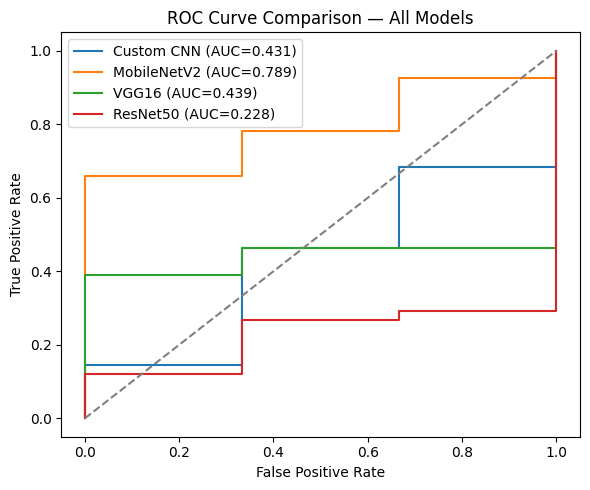

In [18]:
# Combined ROC curve comparison
plt.figure(figsize=(6, 5))
for model, name in [(custom_cnn, "Custom CNN"), (mobilenet_model, "MobileNetV2"),
                     (vgg_model, "VGG16"), (resnet_model, "ResNet50")]:
    y_prob = model.predict(X_test).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison — All Models")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("figures/all_models_roc_comparison.png", dpi=150)
plt.show()


## 9. Grad-CAM Visualization

Grad-CAM highlights the image regions most influential to the model's flood/non-flood prediction,
useful for validating that the model attends to water-like regions rather than spurious cues.

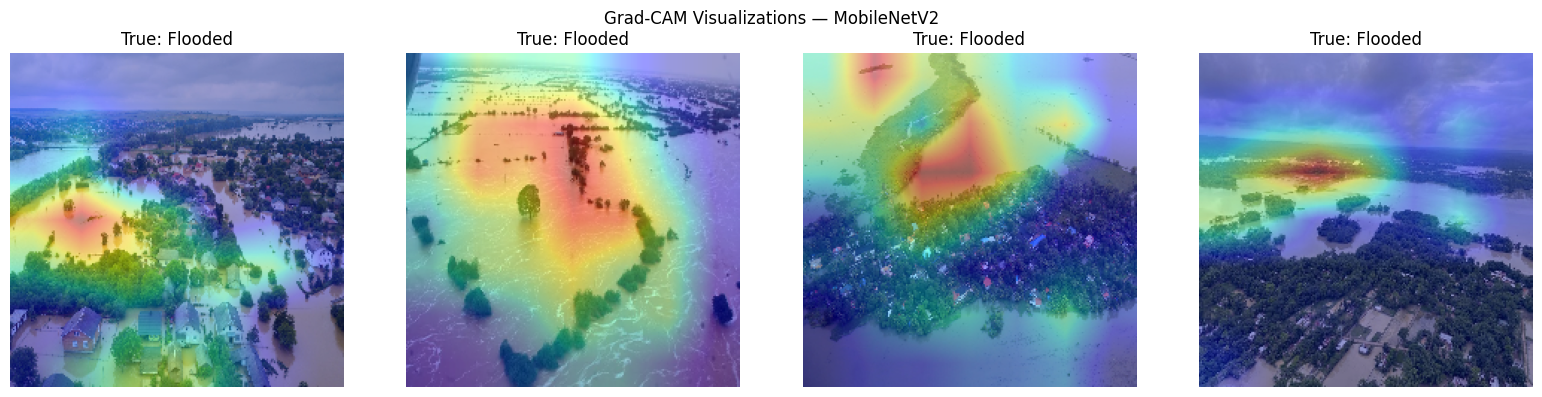

In [19]:
# ============================================================
# 9. GRAD-CAM VISUALIZATION
# ============================================================
# NOTE: mobilenet_base is a nested sub-model inside mobilenet_model. In Keras 3,
# reaching *inside* a nested functional submodel (e.g. via model.get_layer(base.name).output)
# is fragile and can break gradient tracing. Instead, we treat the base model's own
# output (its final feature map) as the Grad-CAM target, and manually re-apply the
# classifier head layers on top of it inside the same GradientTape, so gradients flow
# correctly end-to-end.

def get_head_layers(full_model, base_model):
    """Return the classifier head layers that come after the base model in the graph
    (skips the Input layer and the base model itself)."""
    head = []
    seen_base = False
    for layer in full_model.layers:
        if layer is base_model:
            seen_base = True
            continue
        if seen_base:
            head.append(layer)
    return head

def make_gradcam_heatmap(img_array, full_model, base_model):
    grad_model = models.Model(base_model.input, base_model.output)
    head_layers = get_head_layers(full_model, base_model)

    img_tensor = tf.convert_to_tensor(img_array[np.newaxis, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_output = grad_model(img_tensor, training=False)
        tape.watch(conv_output)
        x = conv_output
        for layer in head_layers:
            x = layer(x, training=False)
        loss = x[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Visualize Grad-CAM on a few test images using the fine-tuned MobileNetV2 model
sample_idxs = np.random.choice(len(X_test), 4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, idx in enumerate(sample_idxs):
    img = X_test[idx]
    heatmap = make_gradcam_heatmap(img, mobilenet_model, mobilenet_base)
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    axes[i].imshow(img)
    axes[i].imshow(heatmap_resized, cmap="jet", alpha=0.4)
    axes[i].set_title(f"True: {['Non-Flooded','Flooded'][y_test[idx]]}")
    axes[i].axis("off")
plt.suptitle("Grad-CAM Visualizations — MobileNetV2")
plt.tight_layout()
plt.savefig("figures/gradcam_visualizations.png", dpi=150)
plt.show()


## 10. Error Analysis

Inspect misclassified test images to understand failure modes (e.g., partial flooding, shadows,
cloud cover, or ambiguous terrain resembling water).

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Number of misclassified test images: 3 / 44


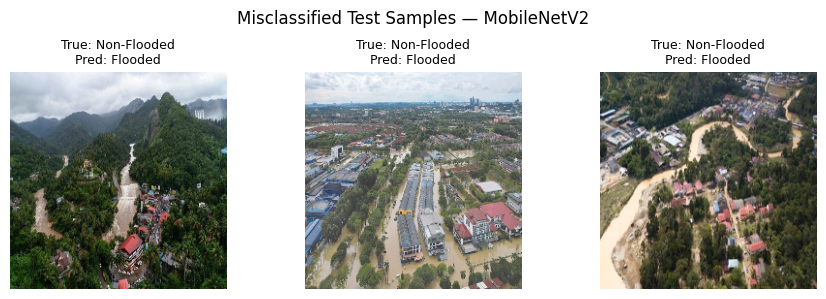

In [20]:
# ============================================================
# 10. ERROR ANALYSIS
# ============================================================
y_prob_best = mobilenet_model.predict(X_test).ravel()
y_pred_best = (y_prob_best > 0.5).astype(int)
misclassified_idx = np.where(y_pred_best != y_test)[0]
print(f"Number of misclassified test images: {len(misclassified_idx)} / {len(y_test)}")

n_show = min(6, len(misclassified_idx))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    chosen = np.random.choice(misclassified_idx, n_show, replace=False)
    for i, idx in enumerate(chosen):
        axes[i].imshow(X_test[idx])
        true_lbl = ["Non-Flooded", "Flooded"][y_test[idx]]
        pred_lbl = ["Non-Flooded", "Flooded"][y_pred_best[idx]]
        axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", fontsize=9)
        axes[i].axis("off")
    plt.suptitle("Misclassified Test Samples — MobileNetV2")
    plt.tight_layout()
    plt.savefig("figures/misclassified_samples.png", dpi=150)
    plt.show()


## 11. Save Final Models

In [21]:
# ============================================================
# 11. SAVE MODELS
# ============================================================
os.makedirs("models", exist_ok=True)
custom_cnn.save("models/custom_cnn_flood_model.keras")
mobilenet_model.save("models/mobilenetv2_flood_model.keras")
vgg_model.save("models/vgg16_flood_model.keras")
resnet_model.save("models/resnet50_flood_model.keras")
print("All models saved to ./models/")


All models saved to ./models/


## 12. Conclusion

This notebook implemented and compared a custom CNN baseline against three transfer-learning
architectures (MobileNetV2, VGG16, ResNet50) for binary flood detection from satellite imagery.
The model comparison table, confusion matrices, ROC curves, and Grad-CAM visualizations above
address the research questions defined in the project proposal (RQ1–RQ5), and the error analysis
highlights common failure modes for future improvement (e.g., additional data, higher-resolution
imagery, or ensembling).